In [1]:
#Imports
try:
    import openmeteo_requests
except:
    !pip install openmeteo-requests
    import openmeteo_requests
try:
    import requests_cache
except:
    !pip install requests-cache
    import requests_cache
try:
    from retry_requests import retry
except:
    !pip install retry-requests
    from retry_requests import retry

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Historical archive endpoint
url = "https://archive-api.open-meteo.com/v1/era5"
# Amsterdam
params = {
"latitude": 52.37,
"longitude": 4.89,
"start_date": "2016-01-01",
"end_date": "2026-02-01",
"hourly": "temperature_2m",
"daily": "temperature_2m_mean"
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]

print(f"Elevation: {response.Elevation()} m")
print(f"Timezone: {response.Timezone()} {response.TimezoneAbbreviation()}")
print(f"UTC Offset (s): {response.UtcOffsetSeconds()}")

# Hourly data
hourly = response.Hourly()
hourly_temp = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {
    "date": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    ),
    "temperature_2m": hourly_temp
}

hourly_dataframe = pd.DataFrame(data=hourly_data)

# Daily data
daily = response.Daily()
daily_temp_mean = daily.Variables(0).ValuesAsNumpy()

daily_data = {
    "date": pd.date_range(
        start=pd.to_datetime(daily.Time(), unit="s", utc=True),
        end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=daily.Interval()),
        inclusive="left"
    ),
    "temperature_2m_mean": daily_temp_mean
}

daily_dataframe = pd.DataFrame(data=daily_data)

print("\nHourly data:")
print(hourly_dataframe.head())

print("\nDaily data:")
print(daily_dataframe.head())

Elevation: 11.0 m
Timezone: None None
UTC Offset (s): 0

Hourly data:
                       date  temperature_2m
0 2016-01-01 00:00:00+00:00           7.022
1 2016-01-01 01:00:00+00:00           7.522
2 2016-01-01 02:00:00+00:00           7.722
3 2016-01-01 03:00:00+00:00           7.372
4 2016-01-01 04:00:00+00:00           6.872

Daily data:
                       date  temperature_2m_mean
0 2016-01-01 00:00:00+00:00             6.411582
1 2016-01-02 00:00:00+00:00             5.680333
2 2016-01-03 00:00:00+00:00             6.922001
3 2016-01-04 00:00:00+00:00             5.153250
4 2016-01-05 00:00:00+00:00             5.599083


### Clean up of data

We have found the data of the temperatures is Amsterdam. We will know be cleaning up the data.

In [3]:
#Clean up data

# Keep only the relevant columns
df = daily_dataframe[["date", "temperature_2m_mean"]].copy()

# Convert dates to ISO format YYYY-MM-DD
df["date"] = pd.to_datetime(df["date"], utc=True).dt.strftime("%Y-%m-%d")
df["date"] = pd.to_datetime(df["date"])

# Keep exactly one row per calendar day
# If duplicates exist, keep the first observation
df = df.drop_duplicates(subset="date").sort_values("date")

# Reindex to a complete daily calendar
full_dates = pd.date_range(start=df["date"].min(), end=df["date"].max(), freq="D")
df = df.set_index("date").reindex(full_dates)
df.index.name = "date"

# Track original missing values before interpolation
df["was_missing"] = df["temperature_2m_mean"].isna()

# Identify consecutive missing blocks
is_missing = df["temperature_2m_mean"].isna()
group_id = (is_missing != is_missing.shift()).cumsum()
missing_block_sizes = is_missing.groupby(group_id).transform("sum")

# interpolate only gaps of size <= 2
short_gap_mask = is_missing & (missing_block_sizes <= 2)

# Interpolate all missing values first
interpolated = df["temperature_2m_mean"].interpolate(method="linear")

# Only fill short gaps
df.loc[short_gap_mask, "temperature_2m_mean"] = interpolated[short_gap_mask]

# Store dates in ISO format
df = df.reset_index()
df["date"] = df["date"].dt.strftime("%Y-%m-%d")

# Save cleaned file
df.to_csv("cleaned_daily_temperature.csv", index=False)

print(df.head())
print("\nRemaining missing observations:")
print(df[df["temperature_2m_mean"].isna()].head())

         date  temperature_2m_mean  was_missing
0  2016-01-01             6.411582        False
1  2016-01-02             5.680333        False
2  2016-01-03             6.922001        False
3  2016-01-04             5.153250        False
4  2016-01-05             5.599083        False

Remaining missing observations:
Empty DataFrame
Columns: [date, temperature_2m_mean, was_missing]
Index: []


We will be splitting the dataset up in three parts.

In [4]:
full_sample = df[
    (df["date"] >= "2016-01-01") &
    (df["date"] <= "2026-02-01")
].copy()

# Training set
training_set = df[
    (df["date"] >= "2016-01-01") &
    (df["date"] <= "2024-12-31")
].copy()

# Test set
test_set = df[
    (df["date"] >= "2025-01-01") &
    (df["date"] <= "2026-02-01")
].copy()

### TASK 1: Deterministic Seasonal Fit

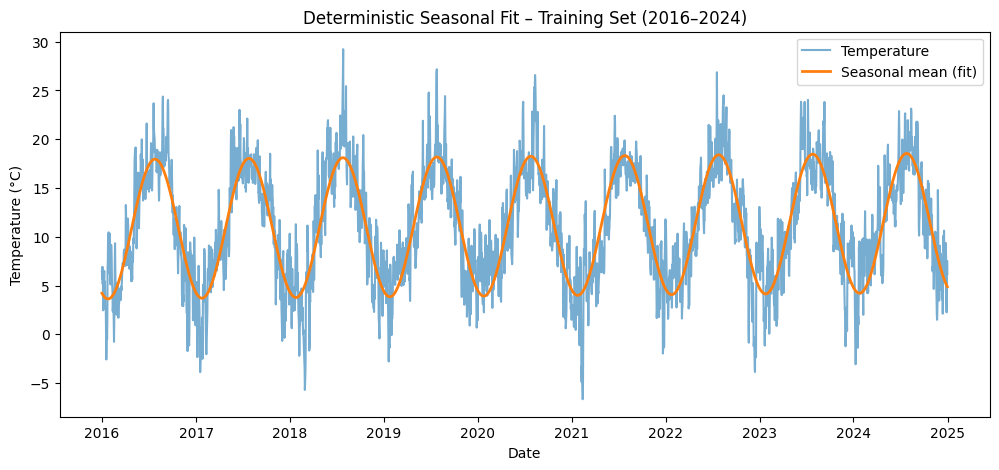

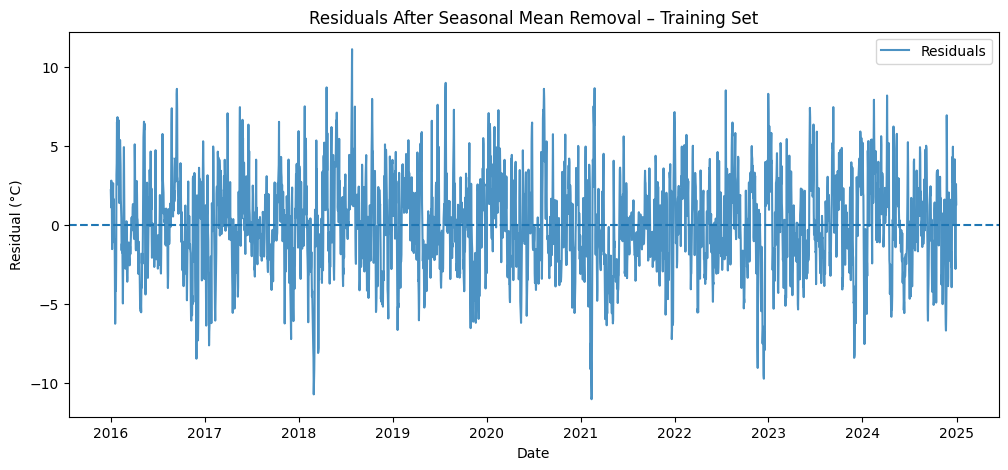

In [5]:

training_set["date"] = pd.to_datetime(training_set["date"])
full_sample["date"] = pd.to_datetime(full_sample["date"])
training_set["t"] = (training_set["date"] - full_sample["date"].min()).dt.days

omega = 2 * np.pi / 365.25

training_set["cos_term"] = np.cos(omega * training_set["t"])
training_set["sin_term"] = np.sin(omega * training_set["t"])

X = training_set[["t", "cos_term", "sin_term"]]
X = sm.add_constant(X)

y = training_set["temperature_2m_mean"]

model = sm.OLS(y, X).fit()

training_set["cos_term"] = np.cos(omega * training_set["t"])
training_set["sin_term"] = np.sin(omega * training_set["t"])

X_train = sm.add_constant(training_set[["t","cos_term","sin_term"]])
training_set["mu_hat"] = model.predict(X_train)

training_set["residual"] = (
    training_set["temperature_2m_mean"] - training_set["mu_hat"]
)

plt.figure(figsize=(12,5))

plt.plot(training_set["date"],
         training_set["temperature_2m_mean"],
         label="Temperature",
         alpha=0.6)

plt.plot(training_set["date"],
         training_set["mu_hat"],
         label="Seasonal mean (fit)",
         linewidth=2)

plt.legend()
plt.title("Deterministic Seasonal Fit – Training Set (2016–2024)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

plt.figure(figsize=(12,5))

plt.plot(training_set["date"],
         training_set["residual"],
         label="Residuals",
         alpha=0.8)

plt.axhline(0, linestyle="--")
plt.legend()
plt.title("Residuals After Seasonal Mean Removal – Training Set")
plt.xlabel("Date")
plt.ylabel("Residual (°C)")

plt.show()

We see a clear good fit for a OLS, however the residuals still can be quite big. We now will save the fit and residuals for the entire sample.

In [6]:

full_sample["t"] = (full_sample["date"] - full_sample["date"].min()).dt.days

full_sample["cos_term"] = np.cos(omega * full_sample["t"])
full_sample["sin_term"] = np.sin(omega * full_sample["t"])

X_full = sm.add_constant(full_sample[["t","cos_term","sin_term"]])

full_sample["mu_hat"] = model.predict(X_full)
full_sample["residual"] = full_sample["temperature_2m_mean"] - full_sample["mu_hat"]
full_sample.to_csv("seasonal_fit_results.csv", index=False)

### TASK 2: Residual Dynamics

In [7]:
training_set["X"] = training_set["residual"]
training_ar = training_set[["date", "X"]].copy()
training_ar["X_lag1"] = training_ar["X"].shift(1)
training_ar = training_ar.dropna()

y = training_ar["X"]
X = training_ar[["X_lag1"]]

ar1_model = sm.OLS(y, X).fit()

phi_hat = ar1_model.params["X_lag1"]
kappa_hat = -np.log(phi_hat)

print(f"phi_hat   = {phi_hat:.6f}")
print(f"kappa_hat = {kappa_hat:.6f}")

eps_hat = ar1_model.resid
sigma_eps_hat = eps_hat.std(ddof=1)

print(f"innovation std = {sigma_eps_hat:.6f}")
print(f"AIC = {ar1_model.aic:.6f}")
print(f"BIC = {ar1_model.bic:.6f}")

phi_hat   = 0.793021
kappa_hat = 0.231906
innovation std = 1.806280
AIC = 13216.107873
BIC = 13222.205603


### Task 3: Seasonal Volatility

In [8]:
training_vol = training_set[["date", "t", "X"]].copy()
training_vol["X_lag1"] = training_vol["X"].shift(1)
training_vol = training_vol.dropna().copy()

full_vol = full_sample[["date", "t"]].copy()
full_vol["X"] = full_sample["residual"]
full_vol["X_lag1"] = full_vol["X"].shift(1)
full_vol = full_vol.dropna().copy()

full_vol["eps_hat"] = full_vol["X"] - phi_hat * full_vol["X_lag1"]


training_vol["eps_hat"] = training_vol["X"] - phi_hat * training_vol["X_lag1"]
training_vol["vol_proxy"] = (
    training_vol["eps_hat"]
    .rolling(window=31, center=True, min_periods=15)
    .std()
)

full_vol["vol_proxy"] = (
    full_vol["eps_hat"]
    .rolling(window=31, center=True, min_periods=15)
    .std()
)

vol_fit = training_vol.dropna(subset=["vol_proxy"]).copy()

vol_fit["sin1"] = np.sin(omega * vol_fit["t"])
vol_fit["cos1"] = np.cos(omega * vol_fit["t"])
vol_fit["sin2"] = np.sin(2 * omega * vol_fit["t"])
vol_fit["cos2"] = np.cos(2 * omega * vol_fit["t"])

X_vol = vol_fit[["t", "sin1", "cos1", "sin2", "cos2"]]
X_vol = sm.add_constant(X_vol)

y_vol = vol_fit["vol_proxy"]

vol_model = sm.OLS(y_vol, X_vol).fit()

print(vol_model.summary())

full_vol["sin1"] = np.sin(omega * full_vol["t"])
full_vol["cos1"] = np.cos(omega * full_vol["t"])
full_vol["sin2"] = np.sin(2 * omega * full_vol["t"])
full_vol["cos2"] = np.cos(2 * omega * full_vol["t"])

X_full_vol = sm.add_constant(full_vol[["t", "sin1", "cos1", "sin2", "cos2"]])

full_vol["sigma_hat"] = vol_model.predict(X_full_vol)
full_vol["sigma_hat"] = full_vol["sigma_hat"].clip(lower=1e-6)

test_vol = full_vol[
    (full_vol["date"] >= "2025-01-01") &
    (full_vol["date"] <= "2026-02-01")
].copy()
full_vol.to_csv("seasonal_volatility_results.csv", index=False)

                            OLS Regression Results                            
Dep. Variable:              vol_proxy   R-squared:                       0.321
Model:                            OLS   Adj. R-squared:                  0.320
Method:                 Least Squares   F-statistic:                     310.6
Date:                Mon, 16 Mar 2026   Prob (F-statistic):          7.86e-273
Time:                        19:16:03   Log-Likelihood:                -930.81
No. Observations:                3287   AIC:                             1874.
Df Residuals:                    3281   BIC:                             1910.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7431      0.011    154.847      0.0

### Monte Carlo Simulation
We now will implement a monte carlo simulation with antithetic sampling.

In [9]:
def simulate_temperature_paths(
    mu_hat_series,
    sigma_hat_series,
    phi_hat,
    x0,
    M=10000
):
    n = len(mu_hat_series)

    # Antithetic variates
    Z_half = np.random.standard_normal((n, M // 2))
    Z = np.concatenate([Z_half, -Z_half], axis=1)

    eps = sigma_hat_series[:, None] * Z

    X = np.zeros((n, M))
    X[0] = phi_hat * x0 + eps[0]

    for i in range(1, n):
        X[i] = phi_hat * X[i - 1] + eps[i]

    T = mu_hat_series[:, None] + X
    return T

def cat_index(T_paths):
    return T_paths.sum(axis=0)

def hdd_index(T_paths, baseline_c):
    return np.maximum(baseline_c - T_paths, 0).sum(axis=0)

def payoff_from_contract(contract_type, T_paths, strike, notional, baseline_c):
    if contract_type == "CAT_CALL":
        idx = cat_index(T_paths)
        payoff = notional * np.maximum(idx - strike, 0.0)

    elif contract_type == "HDD_CALL":
        idx = hdd_index(T_paths, baseline_c=baseline_c)
        payoff = notional * np.maximum(idx - strike, 0.0)

    elif contract_type == "CAT_FUT":
        idx = cat_index(T_paths)
        payoff = notional * idx

    elif contract_type == "HDD_FUT":
        idx = hdd_index(T_paths, baseline_c=baseline_c)
        payoff = notional * idx

    else:
        raise ValueError(f"Unsupported contract type: {contract_type}")

    return payoff

def monte_carlo_price(payoffs, r, tau):
    discounted = np.exp(-r * tau) * payoffs
    price = discounted.mean()
    stderr = discounted.std(ddof=1) / np.sqrt(len(discounted))
    return price, stderr

In [10]:
contract_start = pd.Timestamp("2025-11-01")
contract_end   = pd.Timestamp("2025-11-30")

pricing_df = full_vol[
    (full_vol["date"] >= contract_start) &
    (full_vol["date"] <= contract_end)
].copy()

pricing_df = pricing_df.merge(
    full_sample[["date", "mu_hat", "residual"]],
    on="date",
    how="left"
)

pricing_dates = pricing_df["date"].to_numpy()
mu_hat_series = pricing_df["mu_hat"].to_numpy()
sigma_hat_series = pricing_df["sigma_hat"].to_numpy()

x0_date = contract_start - pd.Timedelta(days=1)

x0_row = full_sample.loc[full_sample["date"] == x0_date, "residual"]

if len(x0_row) == 0:
    raise ValueError("Could not find the initial residual x0 on the day before contract start.")

x0 = float(x0_row.iloc[0])

phi_hat = float(phi_hat)
M = 10000

T_paths = simulate_temperature_paths(
    phi_hat=phi_hat,
    mu_hat_series=mu_hat_series,
    sigma_hat_series=sigma_hat_series,
    x0=x0,
    M=M
)


In [11]:
def price_contract(row, model_df, phi_hat, M=10000):
    valuation_date = pd.to_datetime(row["valuation_date"])
    start_date = pd.to_datetime(row["start_date"])
    end_date = pd.to_datetime(row["end_date"])

    contract_type = row["contract_type"]
    strike = float(row["strike"])
    notional = float(row["notional"])
    baseline_c = float(row["baseline_c"])
    rate = float(row["rate"])

    # Delivery-period model inputs
    pricing_df = model_df[
        (model_df["date"] >= start_date) &
        (model_df["date"] <= end_date)
    ].copy()

    if pricing_df.empty:
        raise ValueError(f"No model data found for contract {row['contract_id']}")

    mu_hat_series = pricing_df["mu_hat"].to_numpy()
    sigma_hat_series = pricing_df["sigma_hat"].to_numpy()

    # Initial residual x0 = last observed residual at valuation date
    hist_df = model_df[model_df["date"] <= valuation_date].copy()
    if hist_df.empty:
        raise ValueError(f"No historical residual available up to valuation date for contract {row['contract_id']}")

    x0 = float(hist_df.iloc[-1]["residual"])

    # Simulate temperatures
    T_paths = simulate_temperature_paths(
        mu_hat_series=mu_hat_series,
        sigma_hat_series=sigma_hat_series,
        phi_hat=phi_hat,
        x0=x0,
        M=M
    )

    # Payoff
    payoffs = payoff_from_contract(
        contract_type=contract_type,
        T_paths=T_paths,
        strike=strike,
        notional=notional,
        baseline_c=baseline_c
    )

    # Discounting
    tau = (end_date - valuation_date).days / 365.25
    price = np.exp(-rate * tau) * payoffs.mean()

    return price

In [12]:
contracts = pd.read_csv("contract_specifications.csv")
contracts["valuation_date"] = pd.to_datetime(contracts["valuation_date"])
contracts["start_date"] = pd.to_datetime(contracts["start_date"])
contracts["end_date"] = pd.to_datetime(contracts["end_date"])
model_df = full_sample[["date", "mu_hat", "residual"]].merge(
    full_vol[["date", "sigma_hat"]],
    on="date",
    how="left"
).sort_values("date")
results = []

for _, row in contracts.iterrows():
    price = price_contract(row, model_df=model_df, phi_hat=phi_hat, M=10000)

    results.append({
        "contract_id": row["contract_id"],
        "price": price
    })

quotes_df = pd.DataFrame(results)
print(quotes_df.head())
quotes_df.to_csv("quoted_prices.csv", index=False)

            contract_id        price
0   CAT_CALL_202501_K94  1067.866603
1  CAT_CALL_202501_K120   673.793784
2  CAT_CALL_202501_K147   361.792488
3  CAT_CALL_202501_K177   151.675052
4  CAT_CALL_202501_K186   112.015518
